# EDIS 8100 · Week 1 · Hello, Learning Analytics

No prior programming experience assumed or required.

Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

---

## Learning objectives

By the end of this notebook you will be able to:

1. **Run** a notebook cell and read what it prints.
2. **Load** a real dataset and describe what one row of it represents.
3. **Make** a bar chart and a histogram, and say what each one is for.
4. **Find** something in this data that the summary numbers were hiding, and explain why it matters.

## How this notebook works (read this if you are new to code)

- Run the cells **top to bottom**. Click a cell, then press **Shift + Enter**.
- **Nothing here can break anything.** This runs on a temporary machine in the cloud, and everything in it is a copy.
- If something goes wrong, the fix is almost always `Runtime > Restart session and run all`.
- Cells marked **Your turn** already contain working code. You can run the whole notebook without typing a thing, then go back and change values.
- Red error text is wordy but harmless. Read the **last line** first.

Today asks you to read the numbers and the charts and to say what you think they mean. Writing code from a blank cell is not asked of you in any week of this course. You are expected to read numbers and pictures and argue about what they mean.

## How to work through this notebook

**Every code cell here runs as written.** You can press Shift and Enter from the top of this notebook to the bottom without editing anything, and nothing will break and nothing will be missing. That is tested before the notebook is published: a clean machine with no data on it runs the whole file end to end.

**The cells marked Your turn already hold a working value.** Changing that value and re-running shows you what the choice was doing to the result, which is why the cell is marked. If you never touch one, you still get every finding this notebook is about. Nothing is missing from a run you did not edit.

**What matters here is what you write in the interpretation cells:** what the method can see, what it cannot, and what you would refuse to conclude from it. A person who runs every cell as written and writes a sharp reading of the output has done the assignment. A person who rewrites the code and writes three vague sentences has not.

**If you work in R, SPSS, or Stata, or have not written code before,** that is the expected starting point here. Read the code the way you read a methods section. You are checking what was done to the data, and you do not need to memorize the syntax. Two patterns cover most of it. Square brackets after a table, as in `df[df.score > 50]`, are subsetting, the same idea as `subset()` or a filter. A line ending in `.mean()`, `.sum()`, or `.value_counts()` is an aggregation, the same idea as `aggregate()` or a frequency table. When a line does not make sense, ask in class rather than working around it.


## Setup

The cell below fetches one file over the internet. Nothing is installed and nothing is saved to your computer.

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

URL = ("https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/main/"
       "uci-student-performance/student-mat.csv")

try:
    students = pd.read_csv(URL, sep=";")
except Exception as e:
    raise SystemExit(
        "Could not download the data.\n"
        "Check that you have an internet connection, then run this cell again.\n"
        "The file lives at github.com/HakeoungLee/edis8100-datasets\n"
        f"(technical detail: {e})")

print(f"Loaded {len(students)} students and {students.shape[1]} columns. You are ready to go.")

Loaded 395 students and 33 columns. You are ready to go.


### Where this data came from

Before you analyse anything, you should be able to say where it came from. It is the first question anyone will ask you about your own dissertation data.

| | |
|---|---|
| **What** | Records for 395 students in a mathematics course at two Portuguese secondary schools |
| **Who collected it** | Paulo Cortez and Alice Silva, from school reports and a student questionnaire |
| **When** | The 2005 to 2006 school year |
| **Licence** | CC BY 4.0. Free to use and share, with attribution |
| **Citation** | Cortez, P., & Silva, A. (2008). Using data mining to predict secondary school student performance. *Proceedings of 5th Future Business Technology Conference*, 5-12. |

These are real teenagers. Their records were anonymised and published so that people could learn from them, which is what we are about to do. Each row is a person.

**One technical note.** This file separates its columns with semicolons rather than commas, which is why the code above says `sep=";"`. The CSV format is only a convention, and a good fraction of the time you spend on real data will be spent finding out which convention somebody used.

## 1. Meet the table

`students.head()` shows the first five rows. Every row is one student. Every column is one thing that was recorded about them.

Notice that the values are words, not codes. You can read a row out loud and understand it.

In [2]:
students.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


**Before you go further.** Pick any row above and read it as a sentence about a person: their school, their age, whether they have internet at home, how far they travel, how their year ended.

Now notice what is **not** here. There is no column for whether they liked the class, whether anything happened at home that year, or whether the teacher was any good. Everything you are about to conclude will be conclusions about **what somebody chose to write down**.

In [3]:
print("Rows (students):", len(students))
print("Columns:", students.shape[1])
print()
print("A few of the columns, and what they hold:")
for col in ["sex", "age", "address", "Medu", "studytime", "absences", "G1", "G2", "G3"]:
    vals = students[col].unique()
    shown = ", ".join(str(v) for v in sorted(vals)[:6])
    more = " ..." if len(vals) > 6 else ""
    print(f"  {col:10} {shown}{more}")

Rows (students): 395
Columns: 33

A few of the columns, and what they hold:
  sex        F, M
  age        15, 16, 17, 18, 19, 20 ...
  address    R, U
  Medu       0, 1, 2, 3, 4
  studytime  1, 2, 3, 4
  absences   0, 1, 2, 3, 4, 5 ...
  G1         3, 4, 5, 6, 7, 8 ...
  G2         0, 4, 5, 6, 7, 8 ...
  G3         0, 4, 5, 6, 7, 8 ...


The codebook that ships with this dataset explains all 33 columns. The ones we need today:

- **`G3`** is the final grade for the year, on a 0 to 20 scale. In Portugal, 10 is a pass.
- **`G1`** and **`G2`** are the first and second period grades.
- **`Medu`** is the mother's education, coded 0 (none) to 4 (higher education).
- **`absences`** is the number of school absences recorded.

## 2. Does a parent's education go with a student's grade?

This is the kind of question learning analytics asks constantly, and it is worth watching how quickly a chart can mislead you.

`groupby` splits the students into groups and computes something for each group. Here, the average final grade for each level of mother's education.

Medu
0    13.00
1     8.68
2     9.73
3    10.30
4    11.76
Name: G3, dtype: float64


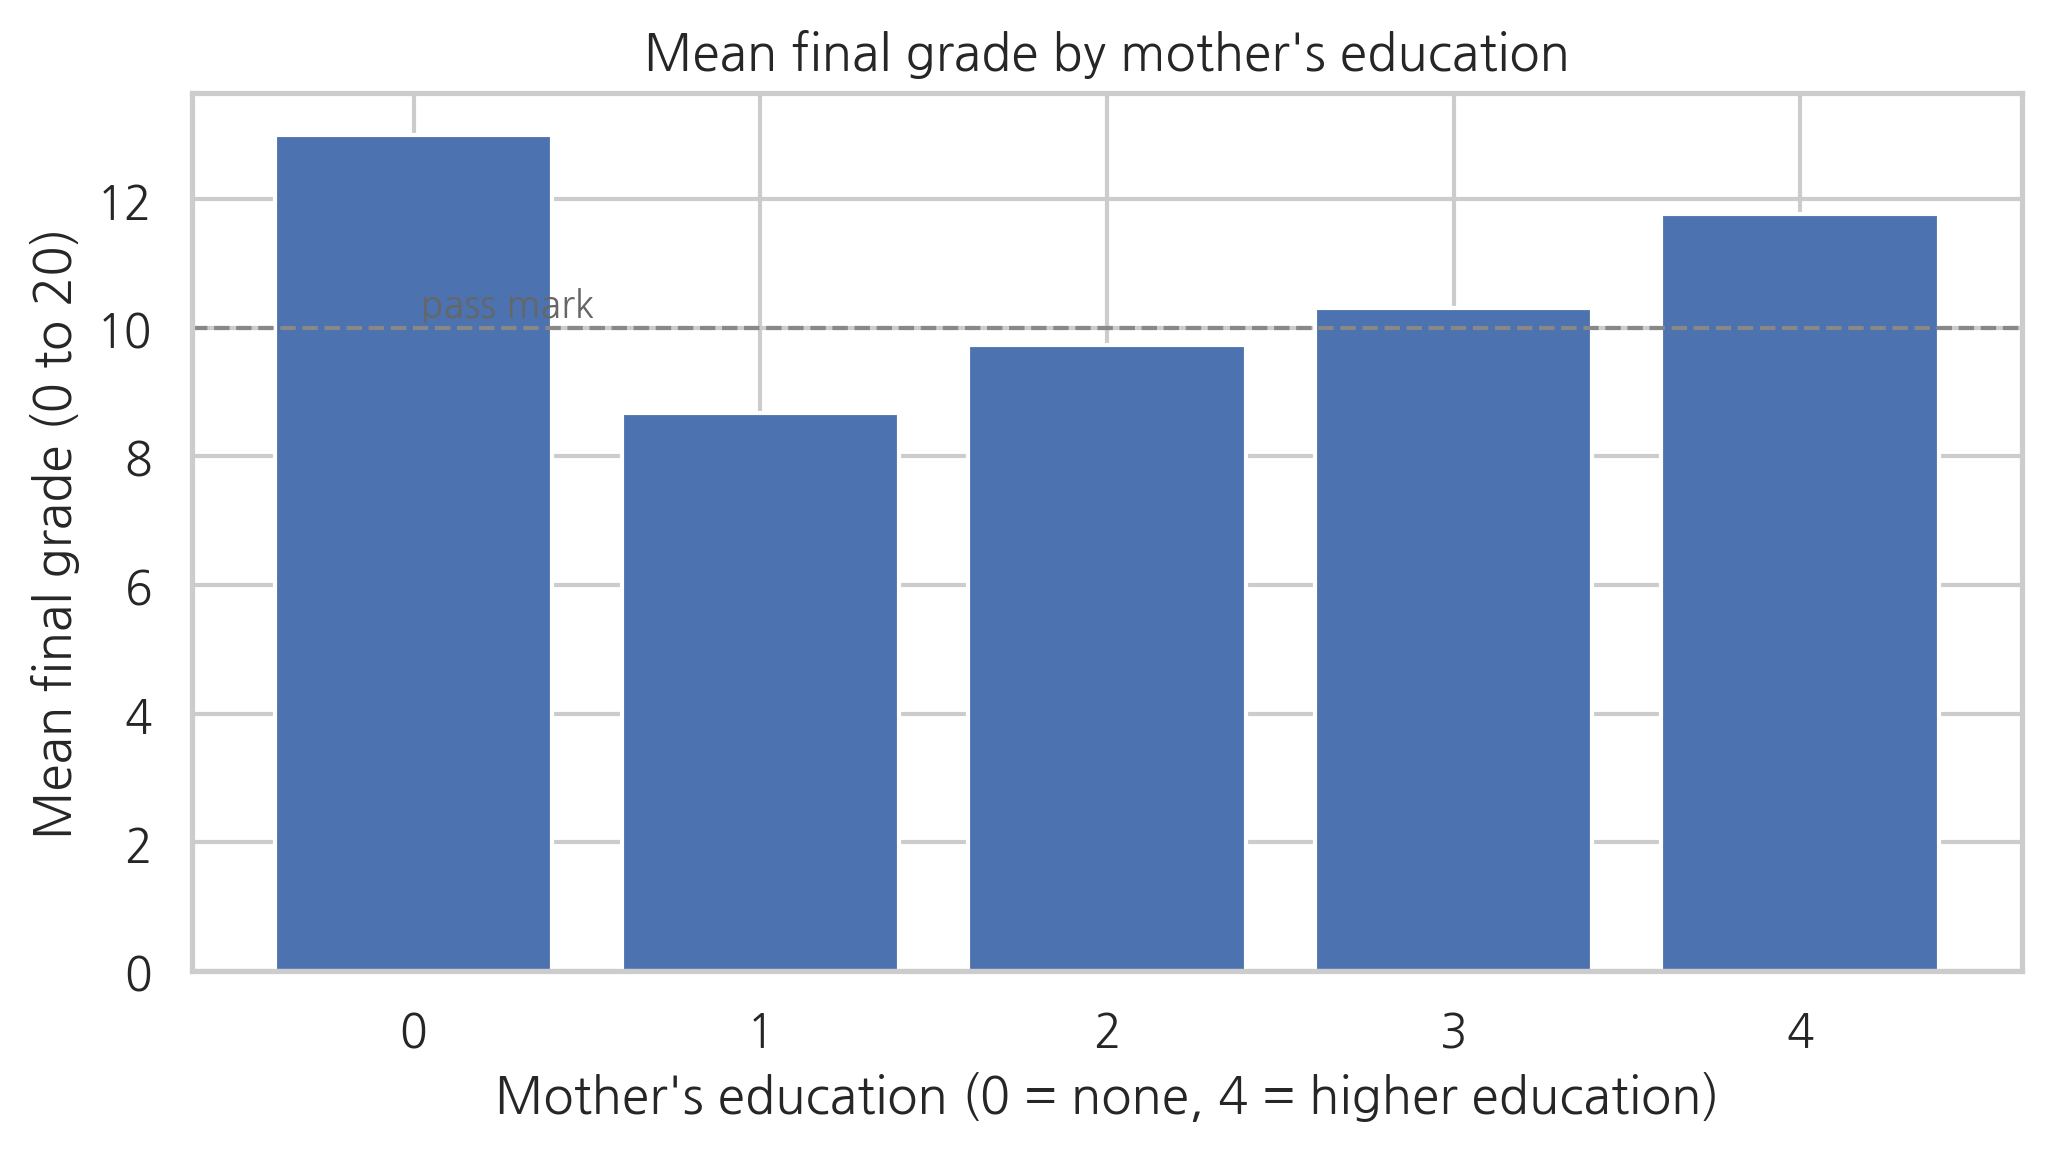

In [4]:
by_medu = students.groupby("Medu")["G3"].mean()
print(by_medu.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(by_medu.index.astype(str), by_medu.values, color="#4C72B0")
ax.set_xlabel("Mother's education (0 = none, 4 = higher education)")
ax.set_ylabel("Mean final grade (0 to 20)")
ax.set_title("Mean final grade by mother's education")
ax.axhline(10, color="#888888", linestyle="--", linewidth=1)
ax.text(0.02, 10.2, "pass mark", color="#666666", fontsize=9)
plt.tight_layout()
plt.show()

**Interpret this chart.** The bars for levels 1 through 4 climb steadily: 8.68, 9.73, 10.30, 11.76. That looks straightforward.

Now look at the tallest bar in the whole chart. It is level 0, mothers with no formal education, at 13.00.

Before you explain that, run the next cell.

In [5]:
counts = students.groupby("Medu")["G3"].agg(["mean", "size"]).round(2)
counts.columns = ["mean grade", "number of students"]
print(counts)
print()
print("The individual grades behind Medu = 0:",
      sorted(students.loc[students["Medu"] == 0, "G3"]))

      mean grade  number of students
Medu                                
0          13.00                   3
1           8.68                  59
2           9.73                 103
3          10.30                  99
4          11.76                 131

The individual grades behind Medu = 0: [9, 15, 15]


The tallest bar in your first chart is three students, with grades of 9, 15 and 15.

One of them did not pass. Nothing is wrong with the data and nothing is wrong with the code. The chart did not show you how many students each bar was computed from.

**The first rule of the course: put the n next to the mean.** A chart that leaves out its denominators will eventually make you say something false in public.

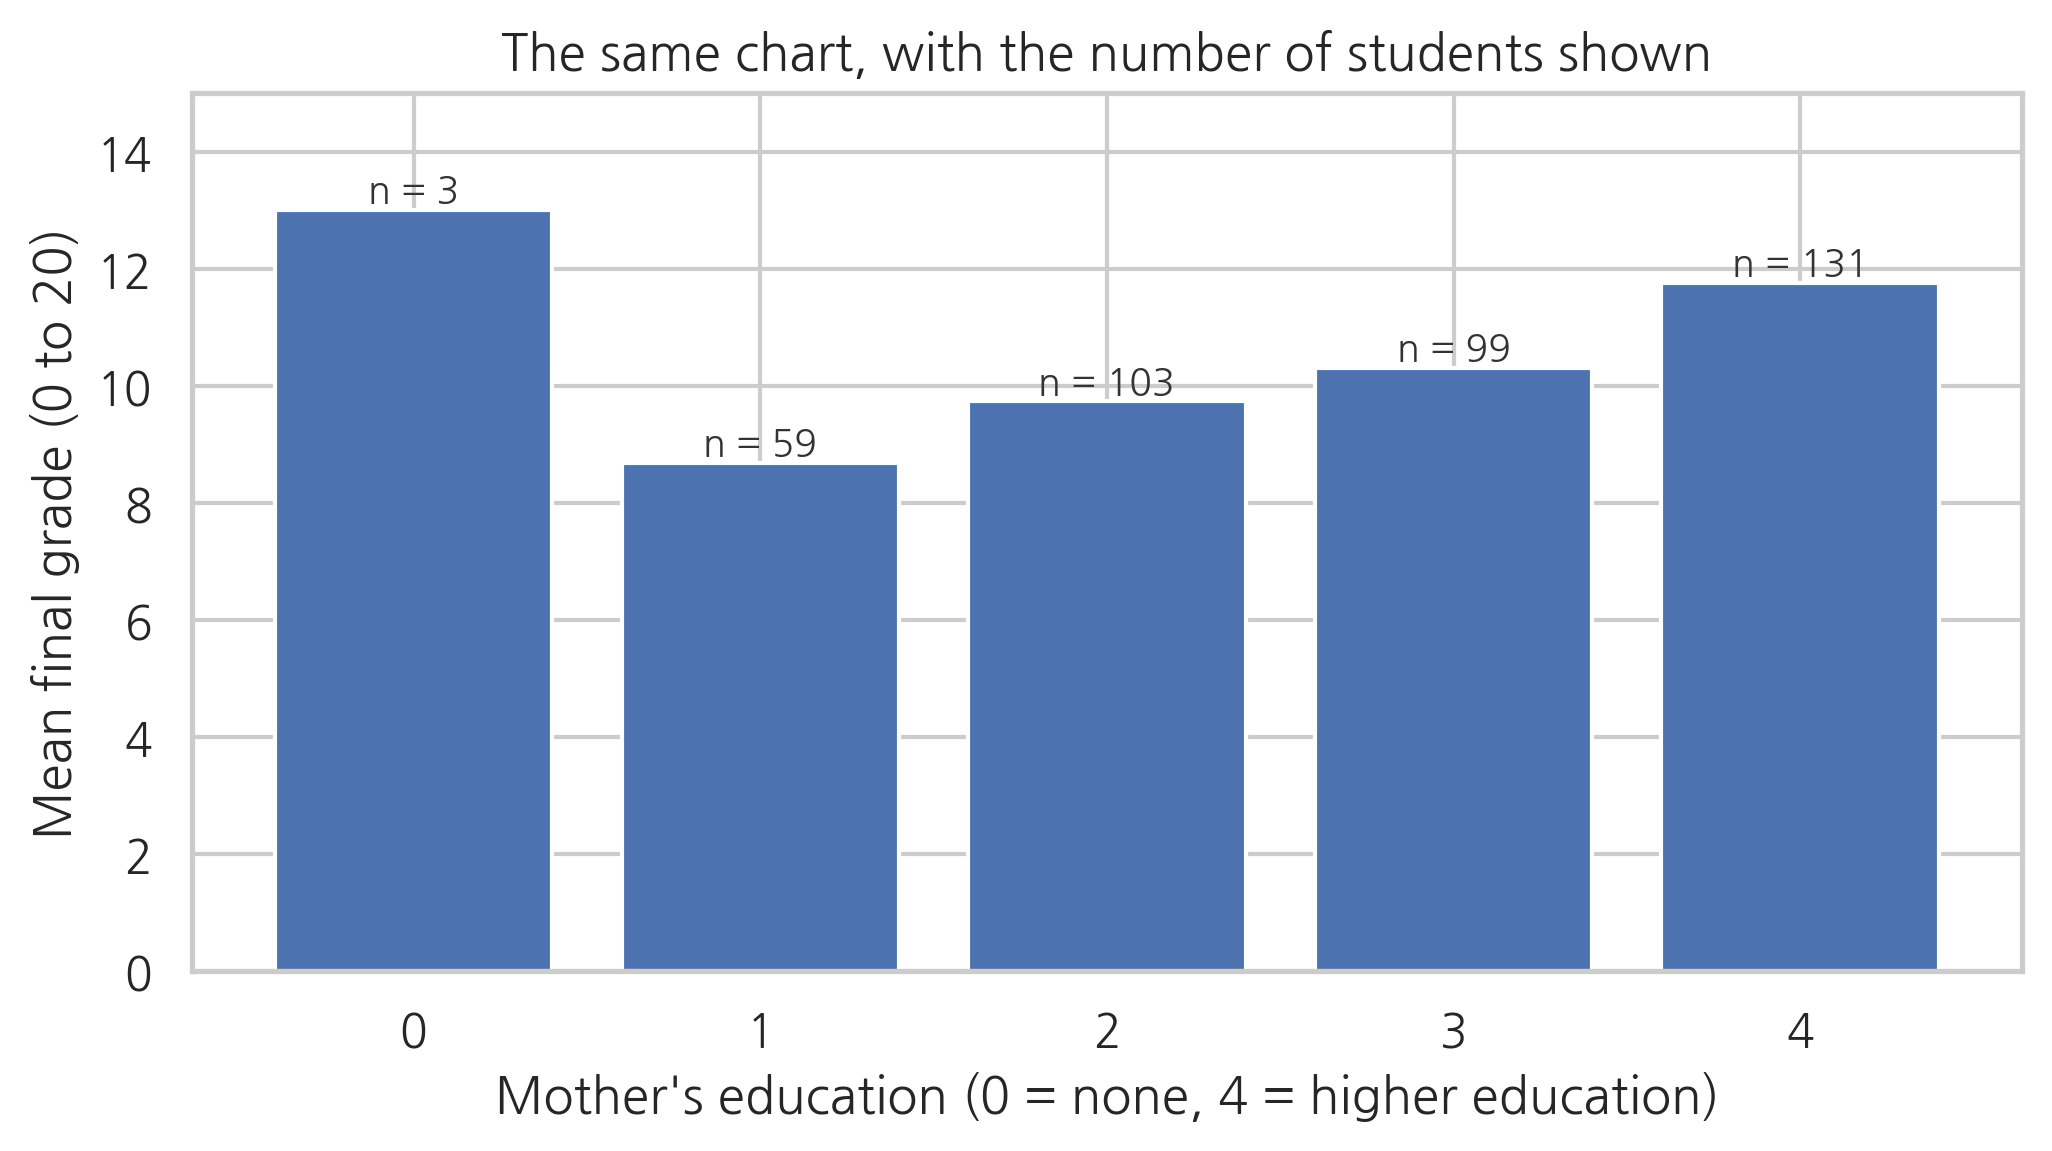

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index.astype(str), counts["mean grade"], color="#4C72B0")
for bar, n in zip(bars, counts["number of students"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"n = {n}", ha="center", fontsize=9, color="#333333")
ax.set_xlabel("Mother's education (0 = none, 4 = higher education)")
ax.set_ylabel("Mean final grade (0 to 20)")
ax.set_title("The same chart, with the number of students shown")
ax.set_ylim(0, 15)
plt.tight_layout()
plt.show()

**Interpret this chart.** Same data, same code, one addition. Which bars would you now be willing to describe to a colleague, and which would you keep quiet about?

**Then the harder question, and it is the one the course will ask you for every week.** Bars 1 through 4 do climb: 8.68, 9.73, 10.30, 11.76, on 59, 103, 99 and 131 students. That gradient is real in this file. Before you write a single sentence about it, name three explanations that are not about the student, in this order.

1. **The instrument.** `Medu` is a number a teenager wrote on a questionnaire about somebody else's schooling, collapsed into five bands. `G3` is a grade a teacher assigned. Neither is a measurement of a student's ability, and a gradient between them can be produced entirely by how the two were recorded.
2. **The setting.** These are two schools with a fixed curriculum, a fixed set of teachers, and a fixed grading practice. What does a school do differently, without meaning to, for a student whose family it already knows well?
3. **The circumstances.** The file does not record hours worked, hours of quiet at home, distance travelled, cost of materials, or who was ill that year. Every one of those is unevenly distributed across these bands and none of them is in the table.

Only after those three is anything about a student a candidate at all. **A gradient across parental education bands is evidence about the conditions people study under, and about a school that produces different outcomes for different circumstances. It is not evidence about the people.** Write down which of the three explanations you would need data on before you would let this chart into a report.

## 3. A histogram

A bar chart compares groups. A histogram shows you the shape of one variable: how many students got each grade.

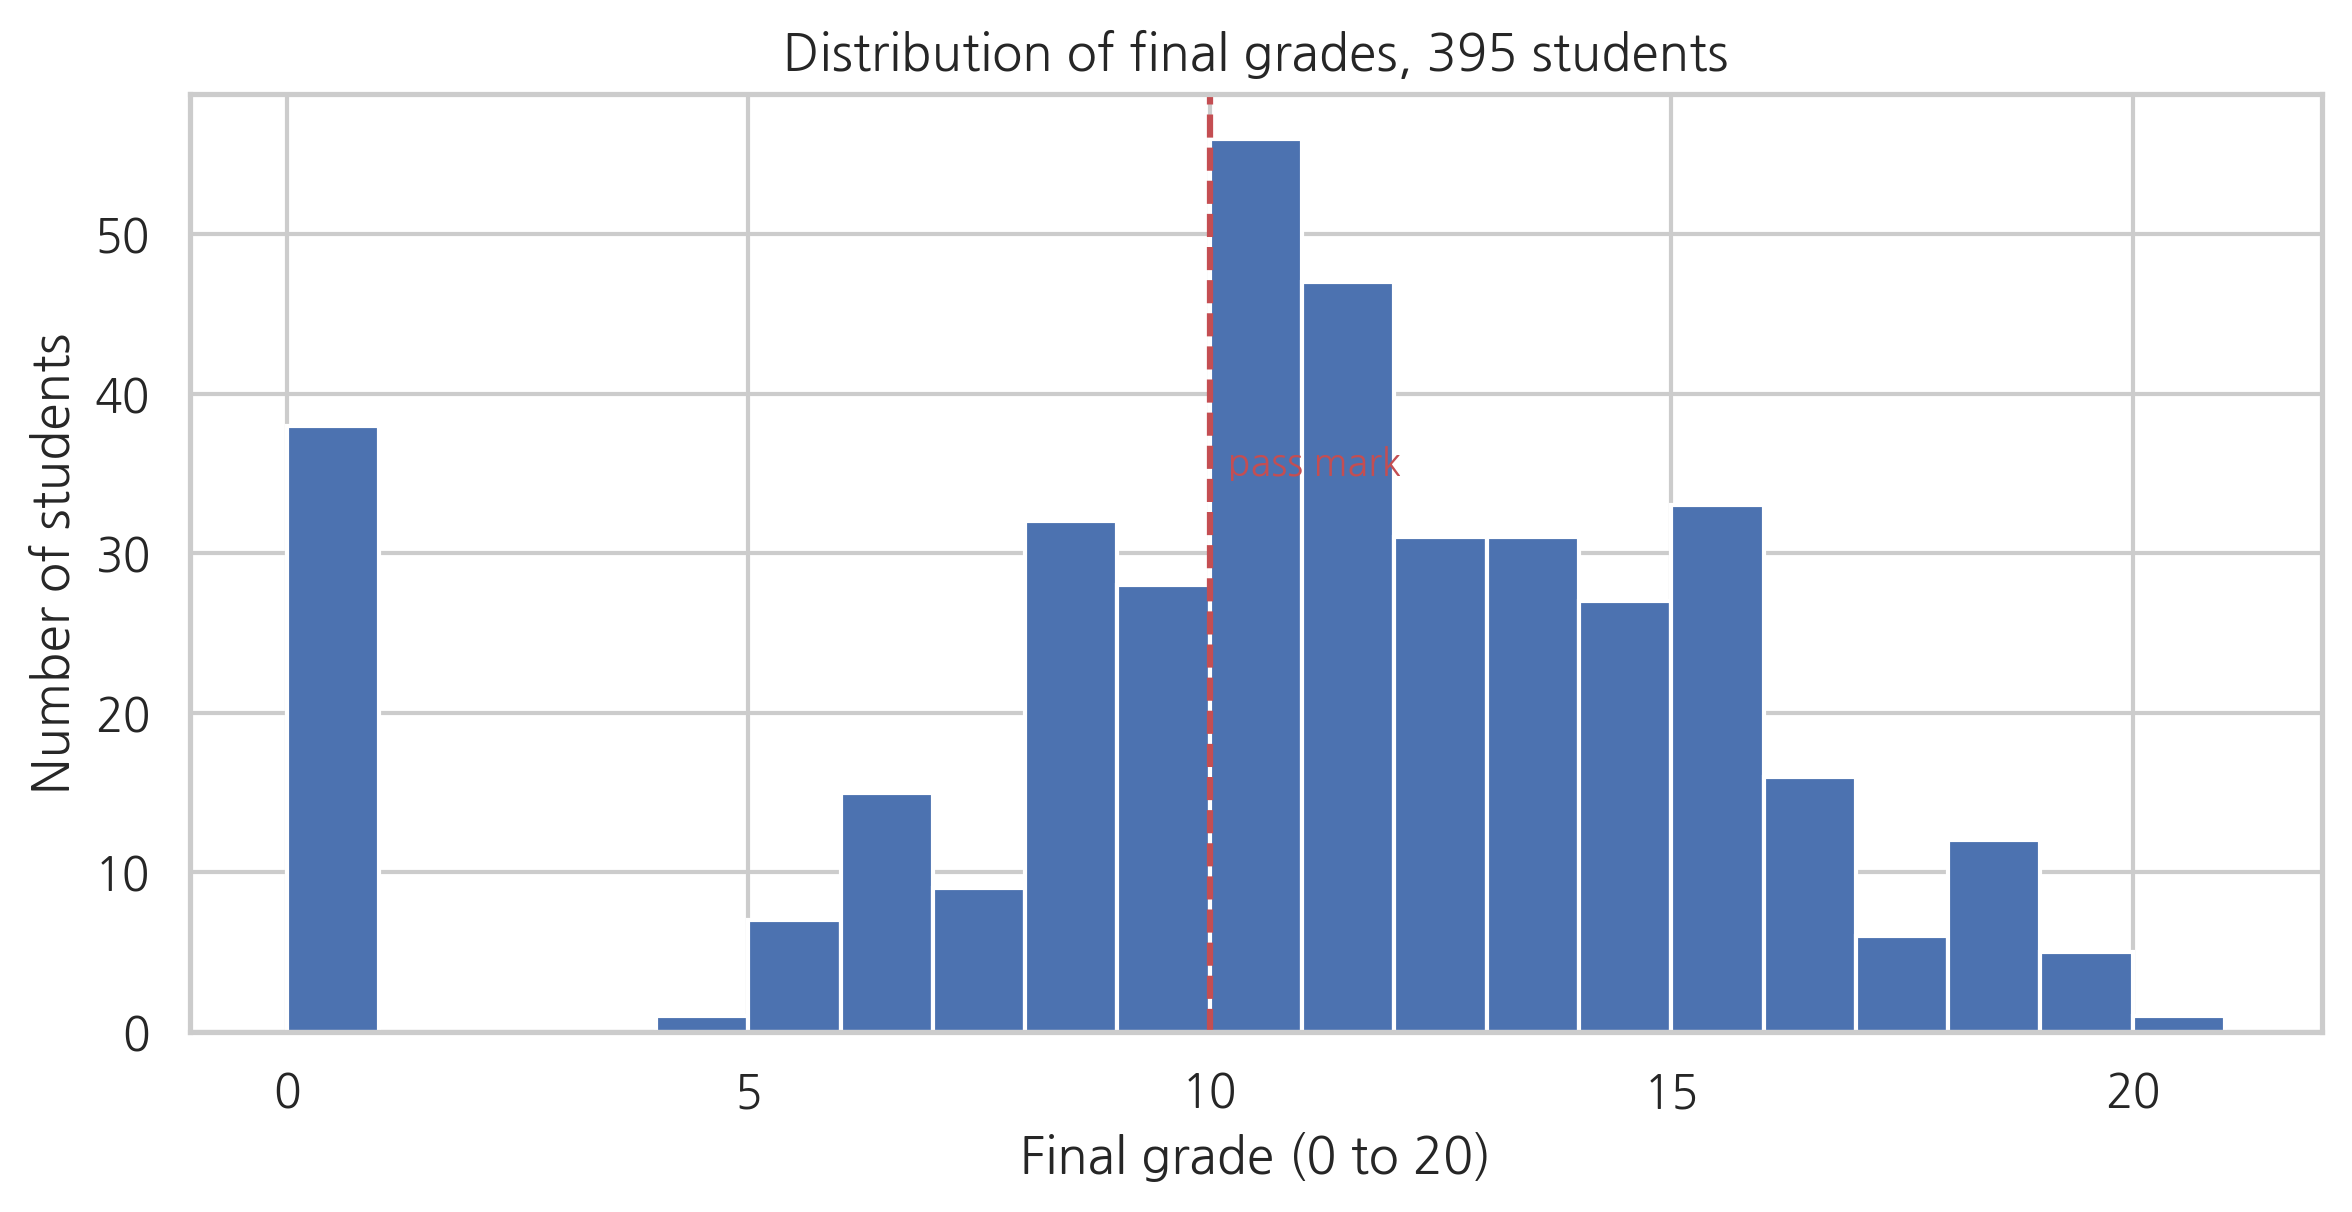

Mean final grade:   10.42
Median final grade: 11.0
Pass rate:          67.1%


In [7]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(students["G3"], bins=range(0, 22), color="#4C72B0", edgecolor="white")
ax.set_xlabel("Final grade (0 to 20)")
ax.set_ylabel("Number of students")
ax.set_title("Distribution of final grades, 395 students")
ax.axvline(10, color="#C44E52", linestyle="--", linewidth=1.5)
ax.text(10.2, 35, "pass mark", color="#C44E52", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Mean final grade:   {students['G3'].mean():.2f}")
print(f"Median final grade: {students['G3'].median():.1f}")
print(f"Pass rate:          {(students['G3'] >= 10).mean():.1%}")

**Interpret this chart.**

Most of it is a rough bell centred around 11, which is what a grade distribution usually looks like. Then there is a tall spike at exactly 0.

Beside it, there are no students at 1, 2 or 3.

If those zeros were bad grades, you would expect a few 1s and 2s next to them. A grade distribution does not usually leave a gap like that. Something else is going on, and the next section finds out what.

## 4. The zeros

Let us look only at the students whose final grade is 0, and ask what else is true of them.

In [8]:
zeros = students[students["G3"] == 0]
others = students[students["G3"] != 0]

print(f"Students with a final grade of 0: {len(zeros)} of {len(students)} ({len(zeros)/len(students):.1%})")
print()
print(f"Of those {len(zeros)} students, how many have zero recorded absences?")
print(f"  {(zeros['absences'] == 0).sum()} of {len(zeros)}")
print()
print("And going the other way, among students with at least one recorded absence:")
with_absence = students[students["absences"] > 0]
print(f"  {len(with_absence)} students, of whom {(with_absence['G3'] == 0).sum()} have a final grade of 0")

Students with a final grade of 0: 38 of 395 (9.6%)

Of those 38 students, how many have zero recorded absences?
  38 of 38

And going the other way, among students with at least one recorded absence:
  280 students, of whom 0 have a final grade of 0


Please read those numbers again slowly.

**All 38** students with a final grade of zero have **zero** recorded absences. And of the **280** students with even one recorded absence, **not one** has a final grade of zero.

That pattern cannot come from students failing. A student who fails a year is a student who was in the building, and the building records absences. What it looks like instead is a set of records where the third period data was never entered, and the blank was stored as a zero.

The next cell offers one more piece of evidence.

In [9]:
print("Second period grade (G2) among the 38:")
print(f"  also 0: {(zeros['G2'] == 0).sum()}")
print(f"  above 0: {(zeros['G2'] > 0).sum()}, ranging from {zeros.loc[zeros['G2'] > 0, 'G2'].min()} to {zeros.loc[zeros['G2'] > 0, 'G2'].max()}")
print()
print("So most of these students were being graded normally in period 2,")
print("and then their period 3 record is a zero with no absences behind it.")

Second period grade (G2) among the 38:
  also 0: 13
  above 0: 25, ranging from 4 to 10

So most of these students were being graded normally in period 2,
and then their period 3 record is a zero with no absences behind it.


## Your turn

The cell below treats those 38 zeros as **missing** rather than as grades, and recomputes the same summary numbers.

Run it as it is first. Then, if you want, change `TREAT_ZEROS_AS_MISSING` to `False` and run it again to see the original numbers.

In [10]:
TREAT_ZEROS_AS_MISSING = True   # <- change this to False and re-run

if TREAT_ZEROS_AS_MISSING:
    grades = students.loc[students["G3"] != 0, "G3"]
    label = "with the 38 zeros treated as missing records"
else:
    grades = students["G3"]
    label = "with the 38 zeros counted as grades"

print(f"Summary {label}:")
print(f"  students included: {len(grades)}")
print(f"  mean final grade:  {grades.mean():.2f}")
print(f"  pass rate:         {(grades >= 10).mean():.1%}")

Summary with the 38 zeros treated as missing records:
  students included: 357
  mean final grade:  11.52
  pass rate:         74.2%


Running it both ways gives you this:

| | mean grade | pass rate |
|---|---|---|
| Zeros counted as grades | 10.42 | 67.1% |
| Zeros treated as missing | 11.52 | 74.2% |

**A pass rate of 67 percent and a pass rate of 74 percent will be read differently.** One of them might trigger a review of the mathematics department. Neither number is a lie. They differ because somebody had to decide what a zero in a spreadsheet means, and nobody wrote that decision down.

You will make a decision exactly like this in every project you do in this course.

## 5. The gap that shrinks

The same problem appears again here. In this file the recorded mean final grade is a little higher for boys than for girls. Watch what happens to that gap when the 38 non-records come out, and watch the interval beside it, because the interval is what tells you whether the gap can be told apart from zero.

In [11]:
from math import sqrt


def gap(df):
    """Mean final grade for each group, the difference, and a 95% interval on it.

    A difference between two group means is an estimate, and an estimate without
    an interval cannot be read. The interval below is the ordinary one for a
    difference between two independent means.
    """
    m = df.loc[df["sex"] == "M", "G3"]
    f = df.loc[df["sex"] == "F", "G3"]
    diff = m.mean() - f.mean()
    se = sqrt(m.var(ddof=1) / len(m) + f.var(ddof=1) / len(f))
    return m.mean(), f.mean(), diff, diff - 1.96 * se, diff + 1.96 * se


m1, f1, g1, lo1, hi1 = gap(students)
m2, f2, g2, lo2, hi2 = gap(others)

print(f"All 395 students: M {m1:.2f}, F {f1:.2f}, difference {g1:.2f}"
      f"   95% interval [{lo1:.2f}, {hi1:.2f}]")
print(f"Excluding the 38: M {m2:.2f}, F {f2:.2f}, difference {g2:.2f}"
      f"   95% interval [{lo2:.2f}, {hi2:.2f}]")
print()
print(f"The 38 non-records are {(zeros['sex'] == 'F').sum()} girls and {(zeros['sex'] == 'M').sum()} boys,")
print("so they do not fall evenly on the two groups.")
print()
print("Now read the second interval before you read the second difference.")


All 395 students: M 10.91, F 9.97, difference 0.95   95% interval [0.05, 1.85]
Excluding the 38: M 11.87, F 11.21, difference 0.66   95% interval [-0.01, 1.33]

The 38 non-records are 23 girls and 15 boys,
so they do not fall evenly on the two groups.

Now read the second interval before you read the second difference.


**Interpret this.** About a third of the apparent difference between the two groups' mean grades was not about anybody's work at all. It was an artifact of which students happened to have a missing record stored as a zero, and those 38 records fell 23 to 15 across the two groups rather than evenly.

Now consider what the intervals do. On all 395 students the difference is 0.95 of a point, with a 95% interval running from about 0.05 to 1.85: small, and just clear of zero. Take the 38 non-records out and what is left is 0.66 of a point with an interval from about **-0.01 to 1.33**. **That interval contains zero.** So the recording artifact shrank the gap by a third, and it also removed the only reason this file had to say there was a gap at all.

Please write down the difference between these two sentences, because you will meet it in every paper you read this semester:

- "Boys scored 0.66 points higher." That is what the point estimate says, and it is not enough to say.
- "The recorded mean grade was 0.66 points higher for boys, 95% interval -0.01 to 1.33, so this file cannot distinguish that difference from no difference." That is what the data supports.

And be careful with the second sentence too. Even if the interval had been far from zero, 0.66 of a point would be a difference in **the grades that were recorded** for two groups in two Portuguese schools in one year. It is not a measurement of either group, and this file holds nothing that could turn it into one: no information about who taught which class, how the grading was done, or what the 395 students' years were like outside the building.

Nobody did anything wrong. A number moved because a recording decision moved, and this course returns to that pattern every week.


## 6. Reflection

Please answer these in the cell below. Two or three sentences each is plenty. Please bring them to the closing discussion.

**1.** Write one sentence describing what the mean final grade of 10.42 measures. Try to write it so that it is true.

**2.** Suppose a school administrator asks you for "the pass rate." You now know there are at least two defensible answers. What would you actually say to them, and what would you need to know before answering?

**3.** Everything you found today came from noticing that a number looked odd and asking what was behind it. Think of a dataset you might use in your own research. Name one number in it that you have never looked behind.

**4.** All three of this week's readings quote the 2011 Banff definition: learning analytics is “the measurement, collection, analysis, and reporting of data about learners and their contexts, for the purposes of understanding and optimizing learning and the environments in which it occurs” (as cited in Siemens, 2013, p. 1382). Lang and colleagues (2022) decline to offer a definition of their own and give four lenses instead. After today, what would you add to that 2011 definition about the gap between what happened and what got recorded?

### Your reflection

*Double-click this cell to edit it. Delete this line and write here.*

**1.**

**2.**

**3.**

**4.**

## 7. Before you leave today

- [ ] I ran every cell in this notebook without an error.
- [ ] I can say what one row of this table represents.
- [ ] I can explain, to someone who was not here, why the tallest bar in the first chart was misleading.
- [ ] I wrote something in the reflection cell above.
- [ ] I signed up for two discussion leadership weeks.

This notebook is not submitted. The Student Info Survey is due on Canvas before we meet again on September 2. Week 2 picks up where this left off, with a much larger dataset from a real university, and the first question there is the same one you just asked: what does this number actually measure?

### A note on AI use

There is nothing from this notebook to upload. Even so, if you used an AI assistant to explain a line of code or to check your reading of a chart, save that exchange now.

From Mini Project 1 in Week 4 onward, the course AI policy requires you to submit your **AI interaction log in a Word file** attached to the Canvas AI Reflection submission, plus your answers to the four reflection questions **in the Canvas text box**. Building the habit this week, when nothing is graded, is much easier than starting it under a deadline.

## Appendix: solutions to the Your turn cell

**Running it both ways.** The two settings give 10.42 against 11.52 on the mean, and 67.1 percent against 74.2 percent on the pass rate.

There is no right answer to which is correct. What is not defensible is reporting either one without saying which choice you made. In a methods section that sentence would read: "Thirty-eight students recorded a final grade of zero. All thirty-eight had zero recorded absences, and no student with a recorded absence scored zero, so these were treated as missing rather than as failing grades."

That sentence is one line long and takes ten seconds to write, and without it a reader has to take the number on trust.

**If you want to go further.** The `absences` column has its own version of the same problem: a mean of 5.71, a median of 4, a maximum of 75, and 29 percent of students sitting at exactly zero. Ask yourself whether every one of those zeros means the same thing.